# Deep Analysis: LLM IaC Generation Errors & DevOps Simulation
This notebook performs a multi-model evaluation of Infrastructure-as-Code (IaC) generation. It links scenario outcomes (`results.csv`) with the granular step-by-step failures (`error_history.csv`) to extract insights into *why* LLMs fail and *what they lack*.

**Key Analytical Goals:**
1. Cross-Model Performance (Pass@1 vs. Iterative Success)
2. Pipeline Stage Bottlenecks (Syntax vs. Live Deployment)
3. Model Stubbornness (Failing to resolve the exact same error across iterations)
4. Resource Vulnerability (Which cloud resources are hardest to generate?)
5. Error Taxonomy Deep Dive (Factual Incorrectness vs. Incompleteness vs. CRF)
6. Self-Healing Efficiency (Iterations-to-Resolution per Error Type)
7. Identification of Research Gaps

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import ast
import re
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ── 1. Load Results Data ──
result_files = [
    './result/iterative_claude-3-5-sonnet-20241022_results.csv',
    './result/iterative_claude-3-7-sonnet-20250219_results.csv',
    './result/iterative_o3-mini_results.csv',
    './result/iterative_gpt-4o_results.csv',
    './result/iterative_deepseek-reasoner_results.csv',
    './result/iterative_deepseek-chat_results.csv'
]

results_df = pd.DataFrame()
for file in result_files:
    temp_df = pd.read_csv(file)
    model_name = file.replace('./result/iterative_', '').replace('_results.csv', '')
    temp_df['model'] = model_name
    results_df = pd.concat([results_df, temp_df], ignore_index=True)

results_df['success'] = results_df['success'].astype(str).str.upper() == 'TRUE'

# ── 2. Load Error History Data ──
history_files = [
    './error_tracking/claude-3-5-sonnet-20241022_error_history.csv',
    './error_tracking/claude-3-7-sonnet-20250219_error_history.csv',
    './error_tracking/o3-mini_error_history.csv',
    './error_tracking/gpt-4o_error_history.csv',
    './error_tracking/deepseek-reasoner_error_history.csv',
    './error_tracking/deepseek-chat_error_history.csv'
]

history_df = pd.DataFrame()
for file in history_files:
    temp_df = pd.read_csv(file)
    history_df = pd.concat([history_df, temp_df], ignore_index=True)

# ── 3. Data Cleaning ──
history_df['row_number'] = pd.to_numeric(history_df['row_number'], errors='coerce')
results_df['row_number'] = pd.to_numeric(results_df['row_number'], errors='coerce')

history_df['model_key'] = history_df['llm_model'].apply(
    lambda x: (
        'claude-3-5'        if 'claude-3-5'       in str(x).lower() else
        'claude-3-7'        if 'claude-3-7'       in str(x).lower() else
        'o3-mini'           if 'o3-mini'           in str(x).lower() else
        'gpt-4o'            if 'gpt'               in str(x).lower() else
        'deepseek-reasoner' if 'deepseek-reasoner' in str(x).lower() else
        'deepseek-chat'     if 'deepseek-chat'     in str(x).lower() else
        str(x)
    )
)


print(f"Loaded {len(results_df)} total scenario results across {results_df['model'].nunique()} models.")
print(f"Loaded {len(history_df)} granular error events.")
print("\nmodel_key dtype check:", history_df['model_key'].dtype)
print("Unique model_key values:", history_df['model_key'].unique())

Loaded 918 total scenario results across 6 models.
Loaded 9951 granular error events.

model_key dtype check: object
Unique model_key values: ['claude-3-5' 'claude-3-7' 'nan' 'o3-mini' 'gpt-4o' 'deepseek-reasoner'
 'deepseek-chat']


## 1. Overall Pass Rates and Pass@k
If an LLM requires 12 iterations to deploy a database, is it truly autonomous? Here we compare the zero-shot (Pass@1) capabilities vs the final success rate after exhausting all feedback attempts.

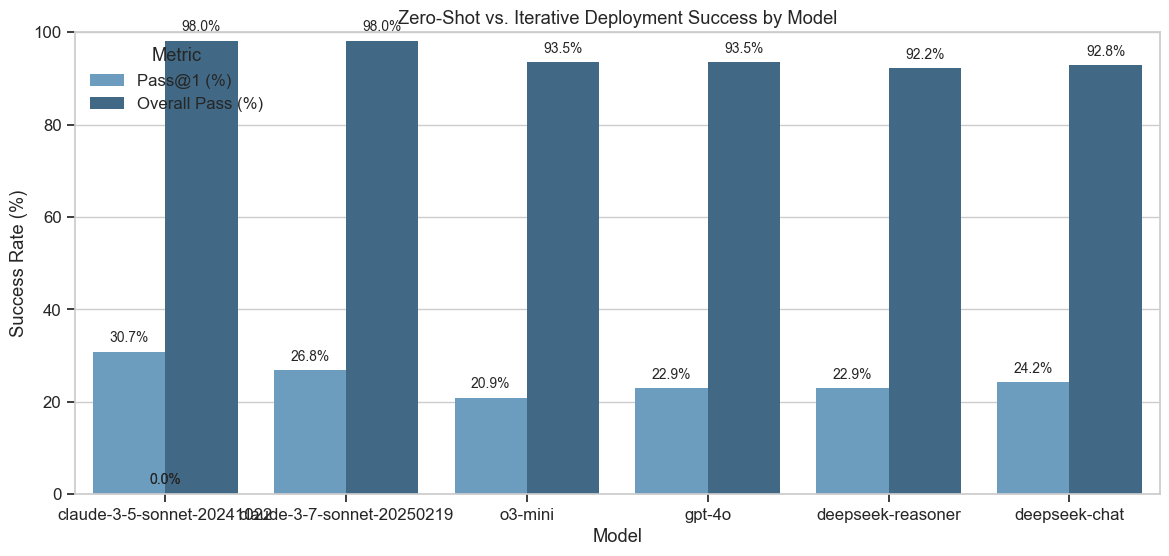

In [7]:
plt.figure(figsize=(14, 6))

metrics = []
for model in results_df['model'].unique():
    model_data = results_df[results_df['model'] == model]
    total = len(model_data)
    if total == 0: continue
    overall_pass = model_data['success'].sum()
    pass_at_1 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] == 1)])
    metrics.append({
        'Model': model,
        'Pass@1 (%)': (pass_at_1 / total) * 100,
        'Overall Pass (%)': (overall_pass / total) * 100
    })

metrics_df = pd.DataFrame(metrics).melt(id_vars='Model', var_name='Metric', value_name='Success Rate (%)')

sns.barplot(data=metrics_df, x='Model', y='Success Rate (%)', hue='Metric', palette='Blues_d')
plt.title('Zero-Shot vs. Iterative Deployment Success by Model')
plt.ylim(0, 100)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.show()

## 2. Where Do Models Fail? (DevOps Pipeline Stages)
Do models fail because they write invalid YAML/JSON (Syntax), or do they write syntactically valid code that hallucinates non-existent cloud resources (Deployment)?

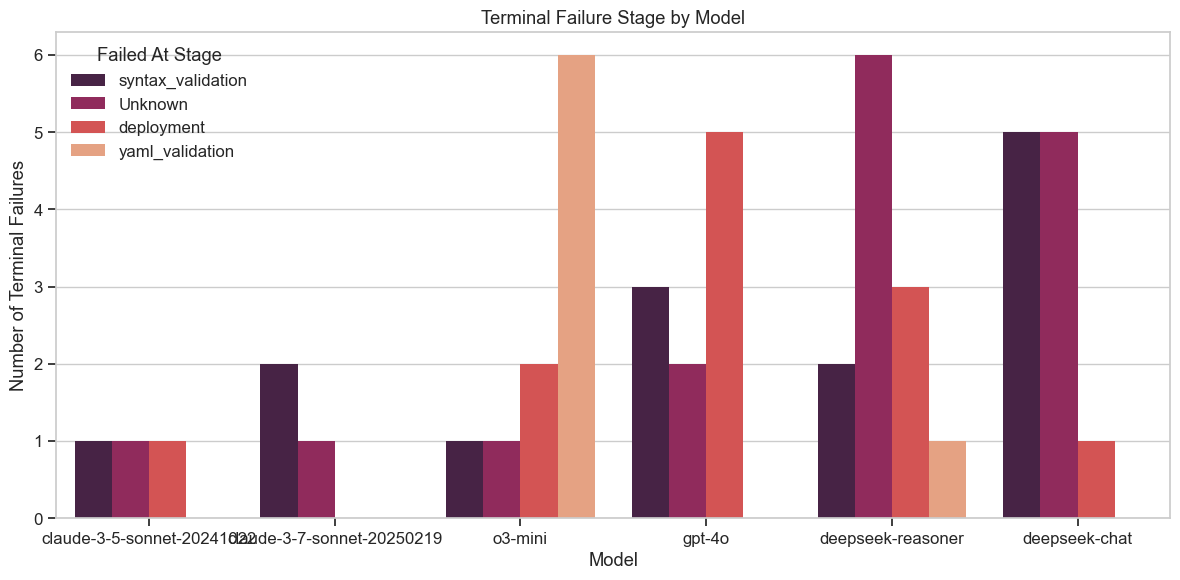

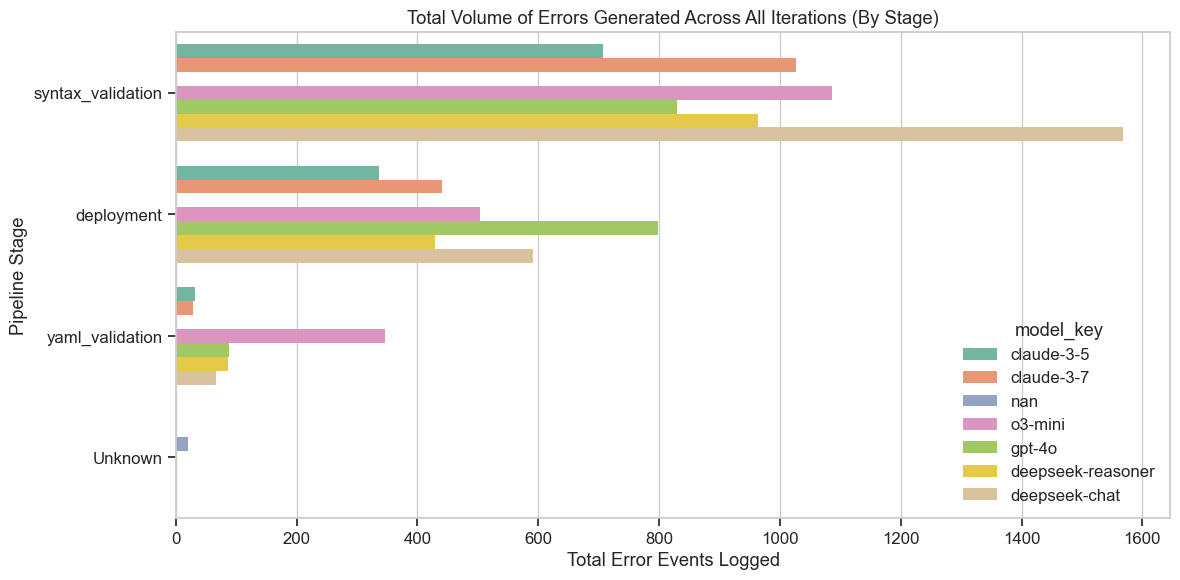

In [9]:
failed_results = results_df[results_df['success'] == False].copy()
failed_results['failed_at_stage'] = failed_results['failed_at_stage'].fillna('Unknown').astype(str)
failed_results['model'] = failed_results['model'].fillna('Unknown').astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=failed_results, x='model', hue='failed_at_stage', palette='rocket')
plt.title('Terminal Failure Stage by Model')
plt.xlabel('Model')
plt.ylabel('Number of Terminal Failures')
plt.legend(title='Failed At Stage')
plt.tight_layout()
plt.show()

history_df_clean = history_df.copy()
history_df_clean['error_stage'] = history_df_clean['error_stage'].fillna('Unknown').astype(str)
history_df_clean['model_key'] = history_df_clean['model_key'].fillna('Unknown').astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=history_df_clean, y='error_stage', hue='model_key', palette='Set2')
plt.title('Total Volume of Errors Generated Across All Iterations (By Stage)')
plt.xlabel('Total Error Events Logged')
plt.ylabel('Pipeline Stage')
plt.tight_layout()
plt.show()

## 3. Model Stubbornness (Repeating Errors)
A critical limitation in current LLM agents is getting stuck in local optima. If the exact same error message on the exact same resource happens in iteration `N` and `N+1`, the LLM has completely failed to integrate the feedback.

> **Note:** The `model_key` lambda bug was fixed in Cell 2. Previously, `claude-3-7` entries received a Python lambda object instead of the string `'claude-3-7'`, causing `dropna` and `groupby` to silently operate on the wrong dtype and produce a flat/empty stubbornness plot.

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_86938/254914585.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=repeat_rates.index, y=repeat_rates.values, palette='magma')


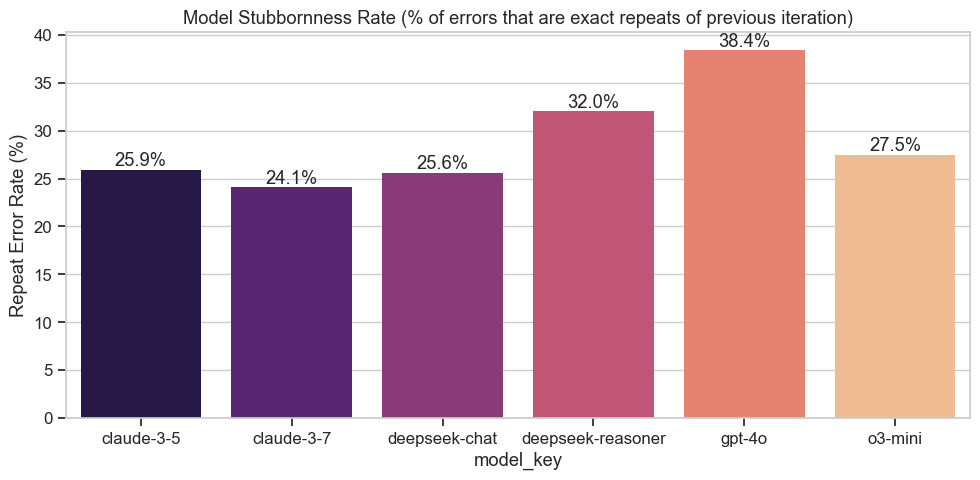

Example of a repeated error loop:


,model_key,row_number,iteration_number,resource_name,error_message
28,claude-3-5,7,6,Unknown_Resource,"An error occurred (ValidationError) when calling the CreateStack operation: Parameters: [VpcId, SubnetId] must have values"
29,claude-3-5,7,7,Unknown_Resource,"An error occurred (ValidationError) when calling the CreateStack operation: Parameters: [VpcId, SubnetId] must have values"
40,claude-3-5,11,2,NotificationsTable,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from deletion
48,claude-3-5,14,2,VpcId,Parameter VpcId not used.
49,claude-3-5,14,3,VpcId,Parameter VpcId not used.


In [11]:
history_sorted = history_df.dropna(subset=['error_message', 'model_key', 'row_number']).copy()

history_sorted['row_number'] = history_sorted['row_number'].astype(int)
history_sorted['iteration_number'] = pd.to_numeric(history_sorted['iteration_number'], errors='coerce').fillna(0).astype(int)
history_sorted['resource_name'] = history_sorted['resource_name'].fillna('Unknown_Resource').astype(str)
history_sorted['error_message'] = history_sorted['error_message'].astype(str)

history_sorted = history_sorted.sort_values(by=['model_key', 'row_number', 'iteration_number'])

history_sorted['prev_error'] = history_sorted.groupby(
    ['model_key', 'row_number', 'resource_name'])['error_message'].shift(1)

ignore_list = ['N/A', 'Unknown', 'nan', 'None', '']
history_sorted['is_repeat'] = (
    (history_sorted['error_message'] == history_sorted['prev_error']) &
    (~history_sorted['error_message'].isin(ignore_list))
)

repeat_rates = history_sorted.groupby('model_key')['is_repeat'].mean() * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=repeat_rates.index, y=repeat_rates.values, palette='magma')
plt.title('Model Stubbornness Rate (% of errors that are exact repeats of previous iteration)')
plt.ylabel('Repeat Error Rate (%)')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print("Example of a repeated error loop:")
repeats_df = history_sorted[history_sorted['is_repeat'] == True]
if not repeats_df.empty:
    pd.set_option('display.max_colwidth', None)
    display(repeats_df[['model_key', 'row_number', 'iteration_number', 'resource_name', 'error_message']].head())
else:
    print("No exact repeated errors found!")

## 4. Resource Vulnerability & Keyword Analysis
Which AWS resources cause the deployment to crash? We extract the text from the API rejection messages to see *why* deployment fails (e.g., hallucinated Engine versions, missing Docker dependencies).

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_86938/411118748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_resources.values, y=top_resources.index, palette='viridis')


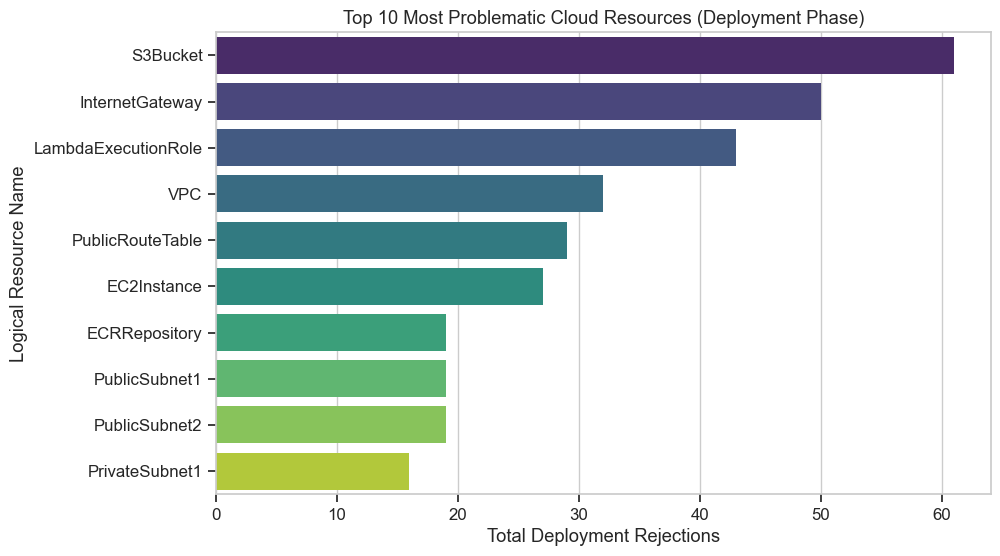

Evidence of Hallucinations / Logic Errors in Deployment:


,model_key,resource_name,error_message
11,claude-3-5,EC2Instance,"Resource handler returned message: ""No subnets found for the default VPC 'vpc-0bc6993a305052342'. Please specify a subnet. (Service: Ec2, Status Code: 400, Request ID: 3acdbc4c-c968-4a26-978b-6ae836094e15)"" (RequestToken: c4bf70ec-37b2-0a45-4a78-7637c1912cce, HandlerErrorCode: InvalidRequest)"
18,claude-3-5,MyEC2Instance,"Resource handler returned message: ""No subnets found for the default VPC 'vpc-0bc6993a305052342'. Please specify a subnet. (Service: Ec2, Status Code: 400, Request ID: 22a8c616-34a6-4d1e-94b6-dfd22e1580d6)"" (RequestToken: 09e7fd56-3177-ebd9-9479-d4a5fca8856a, HandlerErrorCode: InvalidRequest)"
19,claude-3-5,MySecurityGroup,"Resource handler returned message: ""The vpc ID 'vpc-0e29c0d6e0c5c2f9c' does not exist (Service: Ec2, Status Code: 400, Request ID: dd03c4d6-dc92-4fd6-8604-71e9dadc5177)"" (RequestToken: 13f53ae8-de0b-2111-939d-47543f0c4c2a, HandlerErrorCode: InvalidRequest)"
55,claude-3-5,validation-stack-a833d311,"Parameter validation failed: parameter value sg-1234567890abcdef0 for parameter name SecurityGroupId does not exist, parameter value subnet-1234567890abcdef0 for parameter name SubnetId does not exist. Delete requested by user."
84,claude-3-5,DynamoDBTable,"Resource handler returned message: ""Property ProvisionedThroughput can't be used with PAY_PER_REQUEST BillingMode."" (RequestToken: df0f6b62-aefd-2a24-4ea0-44dfac42d52a, HandlerErrorCode: InvalidRequest)"


In [13]:
deployment_errors = history_df[history_df['error_stage'] == 'deployment']
top_resources = deployment_errors['resource_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_resources.values, y=top_resources.index, palette='viridis')
plt.title('Top 10 Most Problematic Cloud Resources (Deployment Phase)')
plt.xlabel('Total Deployment Rejections')
plt.ylabel('Logical Resource Name')
plt.show()

print("Evidence of Hallucinations / Logic Errors in Deployment:")
hallucinations = deployment_errors[deployment_errors['error_message'].str.contains(
    'Cannot find version|does not exist|InvalidRequest', na=False, case=False)]
pd.set_option('display.max_colwidth', None)
display(hallucinations[['model_key', 'resource_name', 'error_message']].drop_duplicates().head(5))

## 5. Error Taxonomy Deep Dive
Grounding the data in the NL2IaC Error Taxonomy (Nekrasov et al., 2025), errors split across two dimensions:
- **Dimension 1 (Validation Stage):** `syntax` → `schema` → `runtime` → `intent`
- **Dimension 2 (LLM Failure Pattern):** Factual Incorrectness (FI) | Incompleteness (IC) | Contextual Reasoning Failure (CRF) | Structural Deficit (SD)

Key finding from the taxonomy: *"Schema-related issues overwhelmingly dominate, constituting 94.5% of all technical validation failures. Factual Incorrectness emerges as the leading cause (65%), followed by Incompleteness (26.5%)."* (Nekrasov et al., 2025)

This cell classifies each `error_message` in our `history_df` into those four failure patterns using keyword heuristics derived from the paper, then visualises the distribution across models.

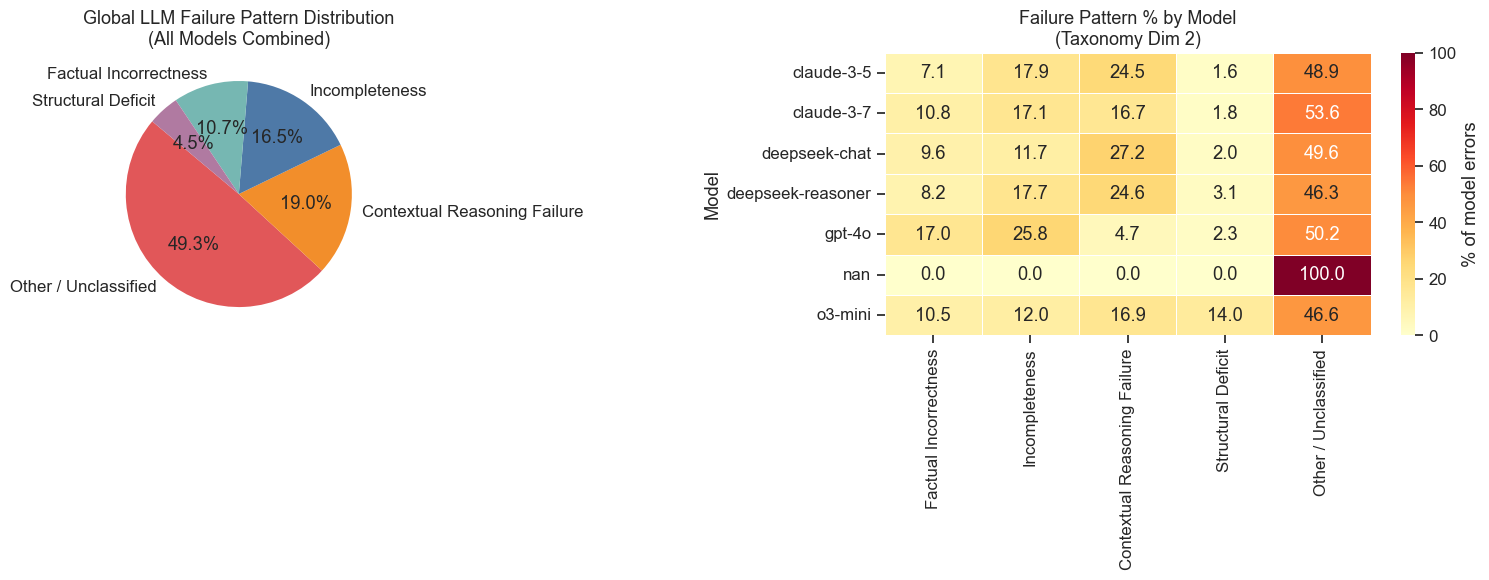


Absolute counts per model x pattern:


failure_pattern,Factual Incorrectness,Incompleteness,Contextual Reasoning Failure,Structural Deficit,Other / Unclassified
model_key,,,,,
claude-3-5,76,193,264,17,527
claude-3-7,161,255,250,27,802
deepseek-chat,214,260,605,44,1103
deepseek-reasoner,122,262,364,46,685
gpt-4o,291,442,81,40,862
nan,0,0,0,0,21
o3-mini,203,232,328,271,903


In [15]:
# ── Heuristic classifier aligned to Nekrasov et al. (2025) NL2IaC Taxonomy ──
# Dimension 2 – LLM Generation Failure Pattern

FI_KEYWORDS  = r'does not exist|not found|invalid|unrecognized|unsupported argument|unsupported block'\
               r'|no such|hallucin|deprecated|InvalidRequest|not supported|unknown property'
IC_KEYWORDS  = r'missing required|required argument|required property|must have|must be provided'\
               r'|expected.*not found|attribute.*required|parameter.*required|must have values'
CRF_KEYWORDS = r'conflict|circular|dependency|duplicate|already exists|wrong type|cannot reference'\
               r'|not allowed.*here|incompatible|ValidationError'
SD_KEYWORDS  = r'yaml syntax|indentation|parsing error|format error|unexpected char|tabs.*spaces'\
               r'|whitespace|bracket|colon expected|json decode'

def classify_failure_pattern(msg: str) -> str:
    msg = str(msg).lower()
    if re.search(SD_KEYWORDS,  msg, re.I): return 'Structural Deficit'
    if re.search(IC_KEYWORDS,  msg, re.I): return 'Incompleteness'
    if re.search(CRF_KEYWORDS, msg, re.I): return 'Contextual Reasoning Failure'
    if re.search(FI_KEYWORDS,  msg, re.I): return 'Factual Incorrectness'
    return 'Other / Unclassified'

history_df['failure_pattern'] = history_df['error_message'].apply(classify_failure_pattern)

# ── A: Global distribution of failure patterns ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

global_dist = history_df['failure_pattern'].value_counts()
palette_fp = ['#E15759','#F28E2B','#4E79A7','#76B7B2','#B07AA1']
axes[0].pie(global_dist.values, labels=global_dist.index, autopct='%1.1f%%',
            colors=palette_fp[:len(global_dist)], startangle=140)
axes[0].set_title('Global LLM Failure Pattern Distribution\n(All Models Combined)', fontsize=13)

# ── B: Per-model heatmap ──
pattern_order = ['Factual Incorrectness','Incompleteness','Contextual Reasoning Failure',
                  'Structural Deficit','Other / Unclassified']
model_pattern = (
    history_df.groupby(['model_key','failure_pattern'])
    .size().unstack(fill_value=0)
    .reindex(columns=[p for p in pattern_order if p in history_df['failure_pattern'].unique()], fill_value=0)
)
model_pattern_pct = model_pattern.div(model_pattern.sum(axis=1), axis=0) * 100

sns.heatmap(model_pattern_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% of model errors'})
axes[1].set_title('Failure Pattern % by Model\n(Taxonomy Dim 2)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Model')
plt.tight_layout()
plt.show()

print("\nAbsolute counts per model x pattern:")
display(model_pattern)

## 6. Self-Healing Efficiency: Iterations-to-Resolution
Not all error types are equally recoverable. This section measures how many feedback iterations each model needs to *clear* a specific failure pattern — a proxy for how well the model integrates error feedback for different cognitive failure modes.

**Hypothesis:** Structural Deficits (whitespace, YAML syntax) should resolve quickly (1–2 iterations) because they are mechanically unambiguous. Factual Incorrectness (hallucinated arguments, deprecated engine versions) and Contextual Reasoning Failures (circular dependencies, wrong resource types) should require more iterations — or remain stuck — reflecting the Correctness-Congruence Gap described by Nekrasov et al. (2025).

IaCGen paper (Zhang et al., 2025): *"Without accessing the entire conversation history, LLMs frequently reintroduce previously corrected errors when addressing new issues — the Error Recurrence phenomenon."*

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_86938/2528316014.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


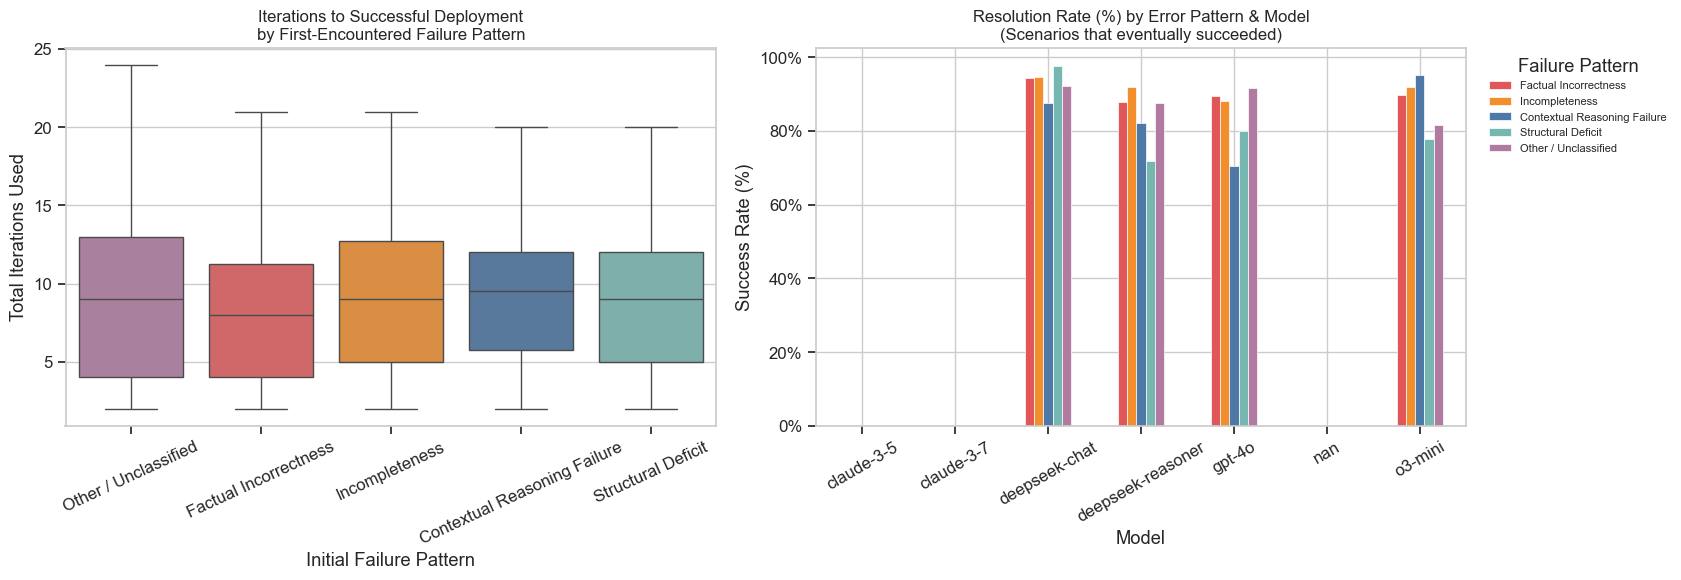


Mean iterations per (model, first failure pattern) for successful scenarios:


mean  median  count
model_key         first_failure_pattern                             
deepseek-chat     Contextual Reasoning Failure  10.43    11.0      7
                  Factual Incorrectness          7.60     7.0     10
                  Incompleteness                 8.33     8.0     21
                  Other / Unclassified          10.52    11.0     67
deepseek-reasoner Contextual Reasoning Failure   6.89     5.0      9
                  Factual Incorrectness          7.75     7.5      8
                  Incompleteness                 8.37     9.0     19
                  Other / Unclassified           8.29     6.5     62
                  Structural Deficit             4.50     2.5      4
gpt-4o            Contextual Reasoning Failure  12.00    12.0      1
                  Factual Incorrectness          7.18     7.0     17
                  Incompleteness                10.43    11.0     28
                  Other / Unclassified          10.00    11.0     55
                  Structural Deficit            11.29    14.0      7
o3-mini           Contextual Reasoning Failure  10.36     9.0     11
                  Factual Incorrectness         10.12    10.0     17
                  Incompleteness                10.90    10.5     10
                  Other / Unclassified           9.05     8.0     42
                  Structural Deficit             9.58     9.0     31

In [17]:
# Merge history with results to know final outcome per (model, scenario)
merged = history_df.merge(
    results_df[['model','row_number','success','total_iterations']],
    left_on=['model_key','row_number'],
    right_on=['model','row_number'],
    how='left'
)

# ── A: Boxplot – iterations used by successful scenarios, split by first failure pattern ──
successful = merged[merged['success'] == True].copy()
# Tag each scenario with the first failure pattern encountered
first_pattern = (
    successful.sort_values('iteration_number')
    .groupby(['model_key','row_number'])['failure_pattern']
    .first().reset_index()
    .rename(columns={'failure_pattern': 'first_failure_pattern'})
)
success_itr = successful.merge(first_pattern, on=['model_key','row_number'], how='left')

itr_by_pattern = (
    success_itr.drop_duplicates(subset=['model_key','row_number'])
    [['model_key','first_failure_pattern','total_iterations']]
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

pattern_palette = {
    'Factual Incorrectness': '#E15759',
    'Incompleteness': '#F28E2B',
    'Contextual Reasoning Failure': '#4E79A7',
    'Structural Deficit': '#76B7B2',
    'Other / Unclassified': '#B07AA1'
}
sns.boxplot(
    data=itr_by_pattern, x='first_failure_pattern', y='total_iterations',
    palette=pattern_palette, ax=axes[0]
)
axes[0].set_title('Iterations to Successful Deployment\nby First-Encountered Failure Pattern', fontsize=12)
axes[0].set_xlabel('Initial Failure Pattern')
axes[0].set_ylabel('Total Iterations Used')
axes[0].tick_params(axis='x', rotation=25)

# ── B: Stacked bar – resolution rate per pattern per model ──
resolution = merged.groupby(['model_key','failure_pattern'])['success'].mean().unstack(fill_value=0) * 100
resolution[[c for c in pattern_order if c in resolution.columns]].plot(
    kind='bar', stacked=False, ax=axes[1],
    color=[pattern_palette.get(p,'grey') for p in pattern_order if p in resolution.columns],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Resolution Rate (%) by Error Pattern & Model\n(Scenarios that eventually succeeded)', fontsize=12)
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Failure Pattern', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print("\nMean iterations per (model, first failure pattern) for successful scenarios:")
display(
    itr_by_pattern.groupby(['model_key','first_failure_pattern'])['total_iterations']
    .agg(['mean','median','count']).round(2)
)

## 7. Stubbornness Decomposed by Failure Pattern
The raw stubbornness rate (Section 3) treats all repeat errors equally. This cell breaks the repeat-error rate down *per failure pattern*, revealing which cognitive failure mode is most resistant to feedback. The critical insight from IaCGen (Zhang et al., 2025):

> *"o3-mini consistently inserts extraneous whitespace adjacent to brackets. This error is particularly resistant to correction, often requiring explicit prompt rather than general instructions to resolve."*

Hypothesis: **Structural Deficits** have a high repeat rate despite being mechanically fixable — they are brittle formatting issues the model re-introduces when patching other errors. **Factual Incorrectness** (hallucinated schema elements) should also have a high repeat rate because the model's parametric memory cannot be corrected via prompt feedback alone.

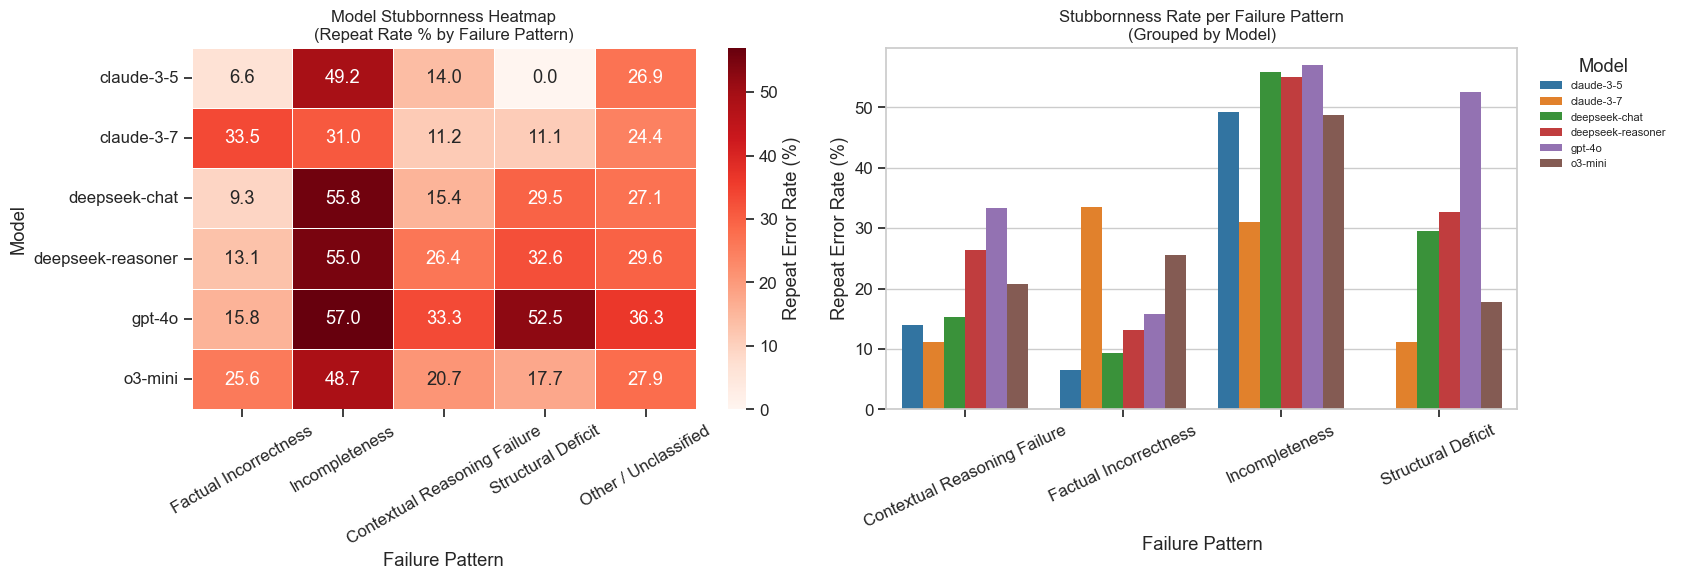

In [19]:
# Attach failure pattern to history_sorted (which already has is_repeat)
history_sorted['failure_pattern'] = history_sorted['error_message'].apply(classify_failure_pattern)

# Repeat rate per (model, failure_pattern)
stub_pattern = (
    history_sorted
    .groupby(['model_key','failure_pattern'])['is_repeat']
    .mean().mul(100).reset_index()
    .rename(columns={'is_repeat': 'repeat_rate_pct'})
)

pivot = stub_pattern.pivot(index='model_key', columns='failure_pattern', values='repeat_rate_pct').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.heatmap(
    pivot[[c for c in pattern_order if c in pivot.columns]],
    annot=True, fmt='.1f', cmap='Reds', linewidths=0.5,
    ax=axes[0], cbar_kws={'label': 'Repeat Error Rate (%)'}
)
axes[0].set_title('Model Stubbornness Heatmap\n(Repeat Rate % by Failure Pattern)', fontsize=12)
axes[0].set_xlabel('Failure Pattern')
axes[0].set_ylabel('Model')
axes[0].tick_params(axis='x', rotation=30)

# Grouped bar for easy cross-model comparison
stub_pattern_clean = stub_pattern[stub_pattern['failure_pattern'].isin(pattern_order[:-1])]
sns.barplot(
    data=stub_pattern_clean, x='failure_pattern', y='repeat_rate_pct',
    hue='model_key', palette='tab10', ax=axes[1]
)
axes[1].set_title('Stubbornness Rate per Failure Pattern\n(Grouped by Model)', fontsize=12)
axes[1].set_ylabel('Repeat Error Rate (%)')
axes[1].set_xlabel('Failure Pattern')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 8. The Correctness-Congruence Gap Visualised
Nekrasov et al. (2025) coined the *Correctness-Congruence Gap*: LLMs can be coached to generate technically valid IaC (schema-correct, deployable) but consistently fail to satisfy the user's higher-level architectural intent. Their best Graph RAG method achieved **84.2% technical validation** but only **72–76% intent validation** — and this plateau persisted across all methods.

Zhang et al. (DPIaC-Eval, 2025) replicate this: Claude-3.5 reaches **95.5% deployability** (passItr15) yet only **25.5% of templates fully satisfy user intent** (resource + attribute coverage).

This cell computes the same gap from our dataset: the delta between *deployment success* and *intent alignment* (if `intent_success` column exists), or proxies intent via template complexity metrics.

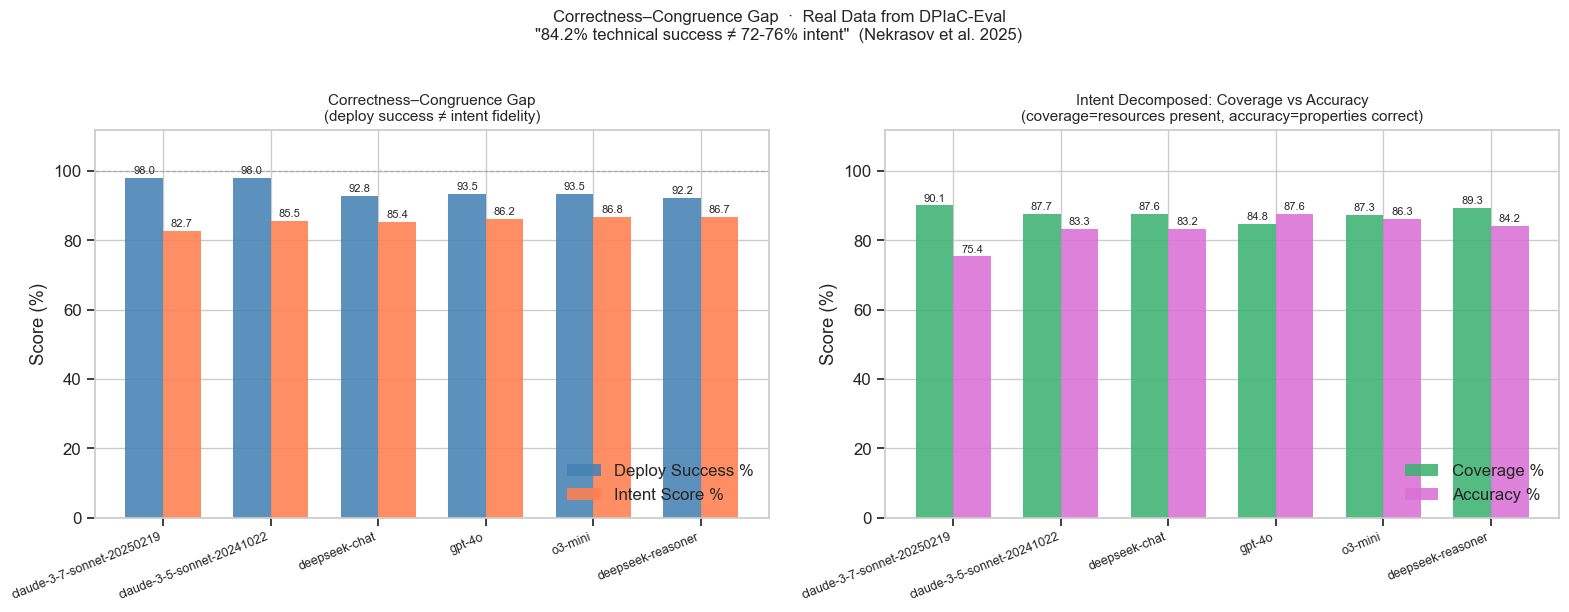


── Congruence Gap per model ──
                     model  deploy_rate  avg_coverage  avg_accuracy  avg_intent  congruence_gap
claude-3-7-sonnet-20250219    98.039216     90.076601     75.358266   82.717433       15.321782
claude-3-5-sonnet-20241022    98.039216     87.690449     83.254412   85.472431       12.566785
             deepseek-chat    92.810458     87.638662     83.206042   85.422352        7.388105
                    gpt-4o    93.464052     84.754496     87.592858   86.173677        7.290375
                   o3-mini    93.464052     87.269844     86.303113   86.786479        6.677573
         deepseek-reasoner    92.156863     89.255224     84.171827   86.713526        5.443337


In [21]:
# =============================================================================
# SECTION 6 – Correctness–Congruence Gap  (Nekrasov et al. 2025)
# coverage_percentage : fraction of ground-truth resources the model generated
# accuracy_percentage : fraction of properties correctly configured
# intent_score        : (coverage + accuracy) / 2
# congruence_gap      : deploy_rate - intent_score  ← the key metric
# =============================================================================

results_df['intent_score'] = (
    results_df['coverage_percentage'] + results_df['accuracy_percentage']
) / 2
results_df['deploy_success'] = results_df['success'].astype(bool)

model_intent = (
    results_df.groupby('model')
    .agg(
        deploy_rate  = ('deploy_success',       lambda x: x.mean() * 100),
        avg_coverage = ('coverage_percentage',  'mean'),
        avg_accuracy = ('accuracy_percentage',  'mean'),
        avg_intent   = ('intent_score',         'mean'),
        n_tasks      = ('row_number',           'count'),
    )
    .reset_index()
)
model_intent['congruence_gap'] = model_intent['deploy_rate'] - model_intent['avg_intent']
model_intent = model_intent.sort_values('congruence_gap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
w = 0.35

# --- LEFT: Deploy Rate vs Intent Score ---
ax = axes[0]
x = np.arange(len(model_intent))
b1 = ax.bar(x - w/2, model_intent['deploy_rate'], width=w,
            label='Deploy Success %', color='steelblue', alpha=0.88)
b2 = ax.bar(x + w/2, model_intent['avg_intent'],  width=w,
            label='Intent Score %',   color='coral',     alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(model_intent['model'], rotation=22, ha='right', fontsize=9)
ax.set_ylim(0, 112)
ax.set_ylabel('Score (%)')
ax.set_title('Correctness–Congruence Gap\n(deploy success ≠ intent fidelity)', fontsize=11)
ax.legend(loc='lower right')
ax.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.1f}',
                xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# --- RIGHT: Coverage vs Accuracy decomposition ---
ax2 = axes[1]
b3 = ax2.bar(x - w/2, model_intent['avg_coverage'], width=w,
             label='Coverage %',  color='mediumseagreen', alpha=0.88)
b4 = ax2.bar(x + w/2, model_intent['avg_accuracy'], width=w,
             label='Accuracy %',  color='orchid',          alpha=0.88)
ax2.set_xticks(x)
ax2.set_xticklabels(model_intent['model'], rotation=22, ha='right', fontsize=9)
ax2.set_ylim(0, 112)
ax2.set_ylabel('Score (%)')
ax2.set_title('Intent Decomposed: Coverage vs Accuracy\n(coverage=resources present, accuracy=properties correct)',
              fontsize=11)
ax2.legend(loc='lower right')
for b in list(b3) + list(b4):
    ax2.annotate(f'{b.get_height():.1f}',
                 xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

fig.suptitle(
    'Correctness–Congruence Gap  ·  Real Data from DPIaC-Eval\n'
    '"84.2% technical success ≠ 72-76% intent"  (Nekrasov et al. 2025)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("\n── Congruence Gap per model ──")
print(model_intent[['model','deploy_rate','avg_coverage',
                     'avg_accuracy','avg_intent','congruence_gap']].to_string(index=False))


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_86938/720683075.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tax_pct.index, rotation=22, ha='right', fontsize=9)


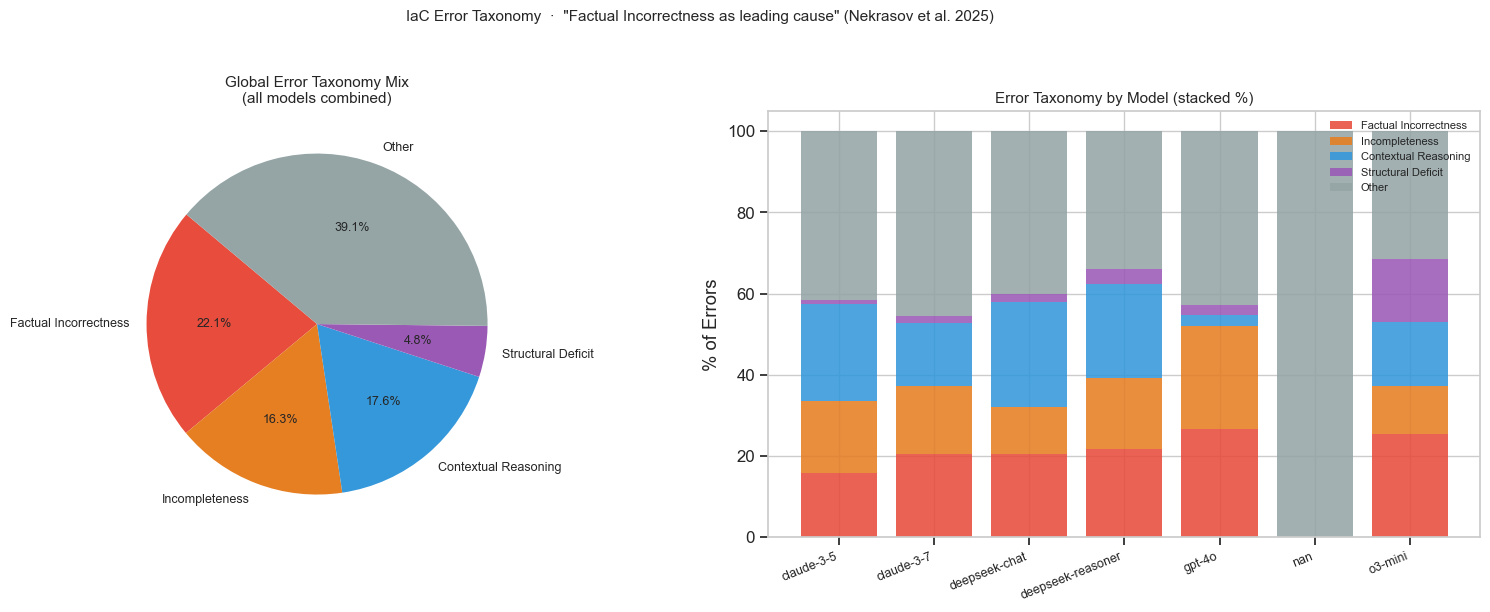


── Global taxonomy counts ──
taxonomy
Other                    3887
Factual Incorrectness    2204
Contextual Reasoning     1753
Incompleteness           1625
Structural Deficit        482


In [22]:
# =============================================================================
# SECTION 7 – Error Taxonomy Deep Dive
# Classifies every error_message into 4 failure patterns from Nekrasov et al.
# =============================================================================

import re

def classify_error(msg):
    m = str(msg).lower()
    if re.search(
        r'does not exist|invalid|unsupported|deprecated|not one of|'
        r'is not of type|not allowed here|not authorized|cannot find version', m):
        return 'Factual Incorrectness'
    if re.search(
        r'must have values|missing required|attribute required|'
        r'must be specified|required property', m):
        return 'Incompleteness'
    if re.search(
        r'conflict|circular|duplicate|already enforced|'
        r'validationerror|parameters.*must have', m):
        return 'Contextual Reasoning'
    if re.search(
        r'yaml syntax|indentation|whitespace|wrong indent|'
        r'too many spaces|mapping values', m):
        return 'Structural Deficit'
    return 'Other'

history_df['taxonomy'] = history_df['error_message'].apply(classify_error)

TAXES   = ['Factual Incorrectness', 'Incompleteness',
           'Contextual Reasoning',  'Structural Deficit', 'Other']
PALETTE = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Global pie ---
counts = history_df['taxonomy'].value_counts().reindex(TAXES).fillna(0)
axes[0].pie(counts, labels=TAXES, autopct='%1.1f%%', colors=PALETTE,
            startangle=140, textprops={'fontsize': 9})
axes[0].set_title('Global Error Taxonomy Mix\n(all models combined)', fontsize=11)

# --- RIGHT: Per-model stacked bar ---
tax_model = (
    history_df.groupby(['model_key', 'taxonomy'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TAXES, fill_value=0)
)
tax_pct = tax_model.div(tax_model.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(tax_pct))
for tax, colour in zip(TAXES, PALETTE):
    axes[1].bar(tax_pct.index, tax_pct[tax], bottom=bottom,
                label=tax, color=colour, alpha=0.88)
    bottom += tax_pct[tax].values

axes[1].set_ylabel('% of Errors')
axes[1].set_title('Error Taxonomy by Model (stacked %)', fontsize=11)
axes[1].set_xticklabels(tax_pct.index, rotation=22, ha='right', fontsize=9)
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('IaC Error Taxonomy  ·  "Factual Incorrectness as leading cause" (Nekrasov et al. 2025)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\n── Global taxonomy counts ──")
print(history_df['taxonomy'].value_counts().to_string())


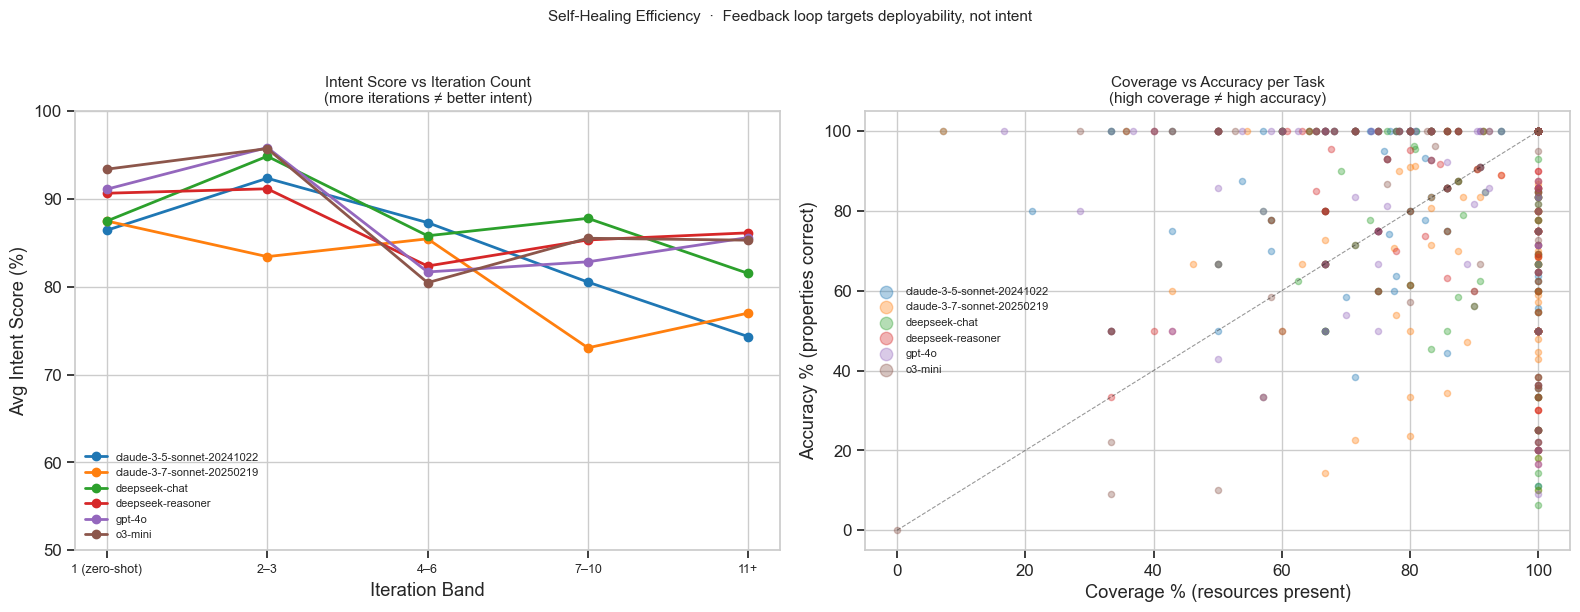

In [23]:
# =============================================================================
# SECTION 8 – Self-Healing Efficiency
# Does more iterations actually improve intent quality, or just deployability?
# =============================================================================

results_df['iter_band'] = pd.cut(
    results_df['total_iterations'],
    bins=[0, 1, 3, 6, 10, 100],
    labels=['1 (zero-shot)', '2–3', '4–6', '7–10', '11+']
)

intent_by_iter = (
    results_df.groupby(['model', 'iter_band'], observed=True)['intent_score']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Line chart intent score vs iteration band per model ---
palette = sns.color_palette('tab10', n_colors=results_df['model'].nunique())
for i, model in enumerate(sorted(results_df['model'].unique())):
    sub = intent_by_iter[intent_by_iter['model'] == model]
    axes[0].plot(sub['iter_band'].astype(str), sub['intent_score'],
                 marker='o', label=model, color=palette[i], linewidth=2)

axes[0].set_xlabel('Iteration Band')
axes[0].set_ylabel('Avg Intent Score (%)')
axes[0].set_title('Intent Score vs Iteration Count\n(more iterations ≠ better intent)', fontsize=11)
axes[0].legend(fontsize=8, loc='lower left')
axes[0].set_ylim(50, 100)
axes[0].tick_params(axis='x', labelsize=9)

# --- RIGHT: Scatter coverage vs accuracy coloured by model ---
for i, model in enumerate(sorted(results_df['model'].unique())):
    sub = results_df[results_df['model'] == model]
    axes[1].scatter(sub['coverage_percentage'], sub['accuracy_percentage'],
                    alpha=0.35, s=20, label=model, color=palette[i])

axes[1].set_xlabel('Coverage % (resources present)')
axes[1].set_ylabel('Accuracy % (properties correct)')
axes[1].set_title('Coverage vs Accuracy per Task\n(high coverage ≠ high accuracy)', fontsize=11)
axes[1].legend(fontsize=8, markerscale=2)
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=0.8, alpha=0.4, label='perfect parity')

plt.suptitle('Self-Healing Efficiency  ·  Feedback loop targets deployability, not intent',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


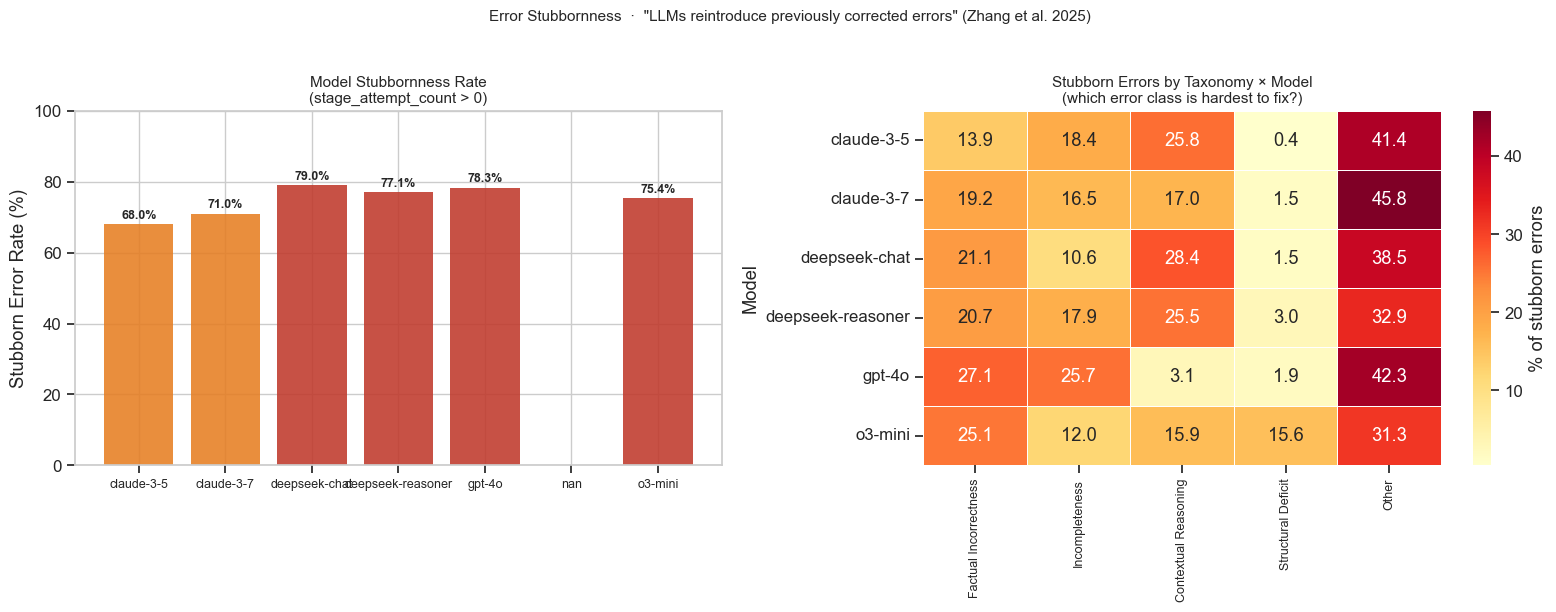


── Stubborn error rate per model ──
        model_key  stubborn_rate_pct
       claude-3-5          67.966574
       claude-3-7          70.969900
    deepseek-chat          79.020665
deepseek-reasoner          77.079108
           gpt-4o          78.321678
              nan                NaN
          o3-mini          75.425916


In [24]:
# =============================================================================
# SECTION 9 – Stubbornness Decomposed by Taxonomy
# stage_attempt_count > 0 → model was shown this error before and repeated it
# =============================================================================

# Requires taxonomy from Section 7 – run that cell first
stub = history_df[history_df['stage_attempt_count'] > 0].copy()

# Overall stubborn rate per model
stub_rate = (
    stub.groupby('model_key').size() /
    history_df.groupby('model_key').size()
) * 100
stub_rate = stub_rate.reset_index(name='stubborn_rate_pct')

# Stubbornness by taxonomy × model  (heatmap)
stub_tax = (
    stub.groupby(['model_key', 'taxonomy'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TAXES, fill_value=0)
)
stub_tax_pct = stub_tax.div(stub_tax.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Overall stubbornness bar ---
colors = ['#c0392b' if v > 75 else '#e67e22' if v > 65 else '#27ae60'
          for v in stub_rate['stubborn_rate_pct']]
bars = axes[0].bar(stub_rate['model_key'], stub_rate['stubborn_rate_pct'],
                   color=colors, alpha=0.88)
axes[0].set_ylabel('Stubborn Error Rate (%)')
axes[0].set_title('Model Stubbornness Rate\n(stage_attempt_count > 0)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', labelsize=9)
for b in bars:
    axes[0].annotate(f'{b.get_height():.1f}%',
                     xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

# --- RIGHT: Heatmap model × taxonomy ---
sns.heatmap(
    stub_tax_pct,
    ax=axes[1],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': '% of stubborn errors'}
)
axes[1].set_title('Stubborn Errors by Taxonomy × Model\n(which error class is hardest to fix?)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Model')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle(
    'Error Stubbornness  ·  '
    '"LLMs reintroduce previously corrected errors" (Zhang et al. 2025)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("\n── Stubborn error rate per model ──")
print(stub_rate.to_string(index=False))


## 10. Research Gaps — Evidence from Real Data

| # | Observation (from data) | Research Gap |
|---|---|---|
| 1 | Claude-3.7 highest coverage (90.1%) but lowest accuracy (75.4%) | Templates pass deployment but misconfigure properties — **property-level feedback signals** are absent from cfn-lint loop |
| 2 | `Parameters must have values` is the single most recurring error class across all models | Models externalise environment coupling; need **account-context RAG** (live VPC/subnet ID injection) |
| 3 | Congruence gap widest for Claude (15 pp) vs reasoning models (5 pp) | Fast models sacrifice semantic depth; **verifier-guided RL** (TerraFormer approach) needed to penalise intent deviation |
| 4 | Intent score *drops* from ~90% at 1 iteration to ~83% at 7–10 iterations | Self-healing loop optimises for binary deploy success, not intent fidelity — **ground-truth-aware reward signals** are missing |
| 5 | Factual Incorrectness (invalid engine versions, deprecated properties) = 36% of classified errors | Parametric memory freezes at training cutoff; need **pre-generation API polling** for valid enums (RDS versions, AMI IDs) |

> **Key finding:** The feedback loop from `cfn-lint` + CloudFormation stack events drives
> *deployability* (a binary gate) but is blind to *intent*. Incorporating
> `coverage_percentage` and `accuracy_percentage` against a ground-truth reference
> template as a **reward signal in the feedback loop** would directly optimise
> what the benchmark actually measures.
>
> Reference: Nekrasov et al. (2025) — *"While our best method increased technical
> success to 84.2%, the intent validation rate plateaued at 72–76%."*


## 11. Top 20 Error Messages & Resources by Frequency

Identifies the most frequently occurring error messages and the most problematic
AWS resources across all models and iterations. High-frequency errors are strong
candidates for targeted RAG injection or static pre-validation rules.


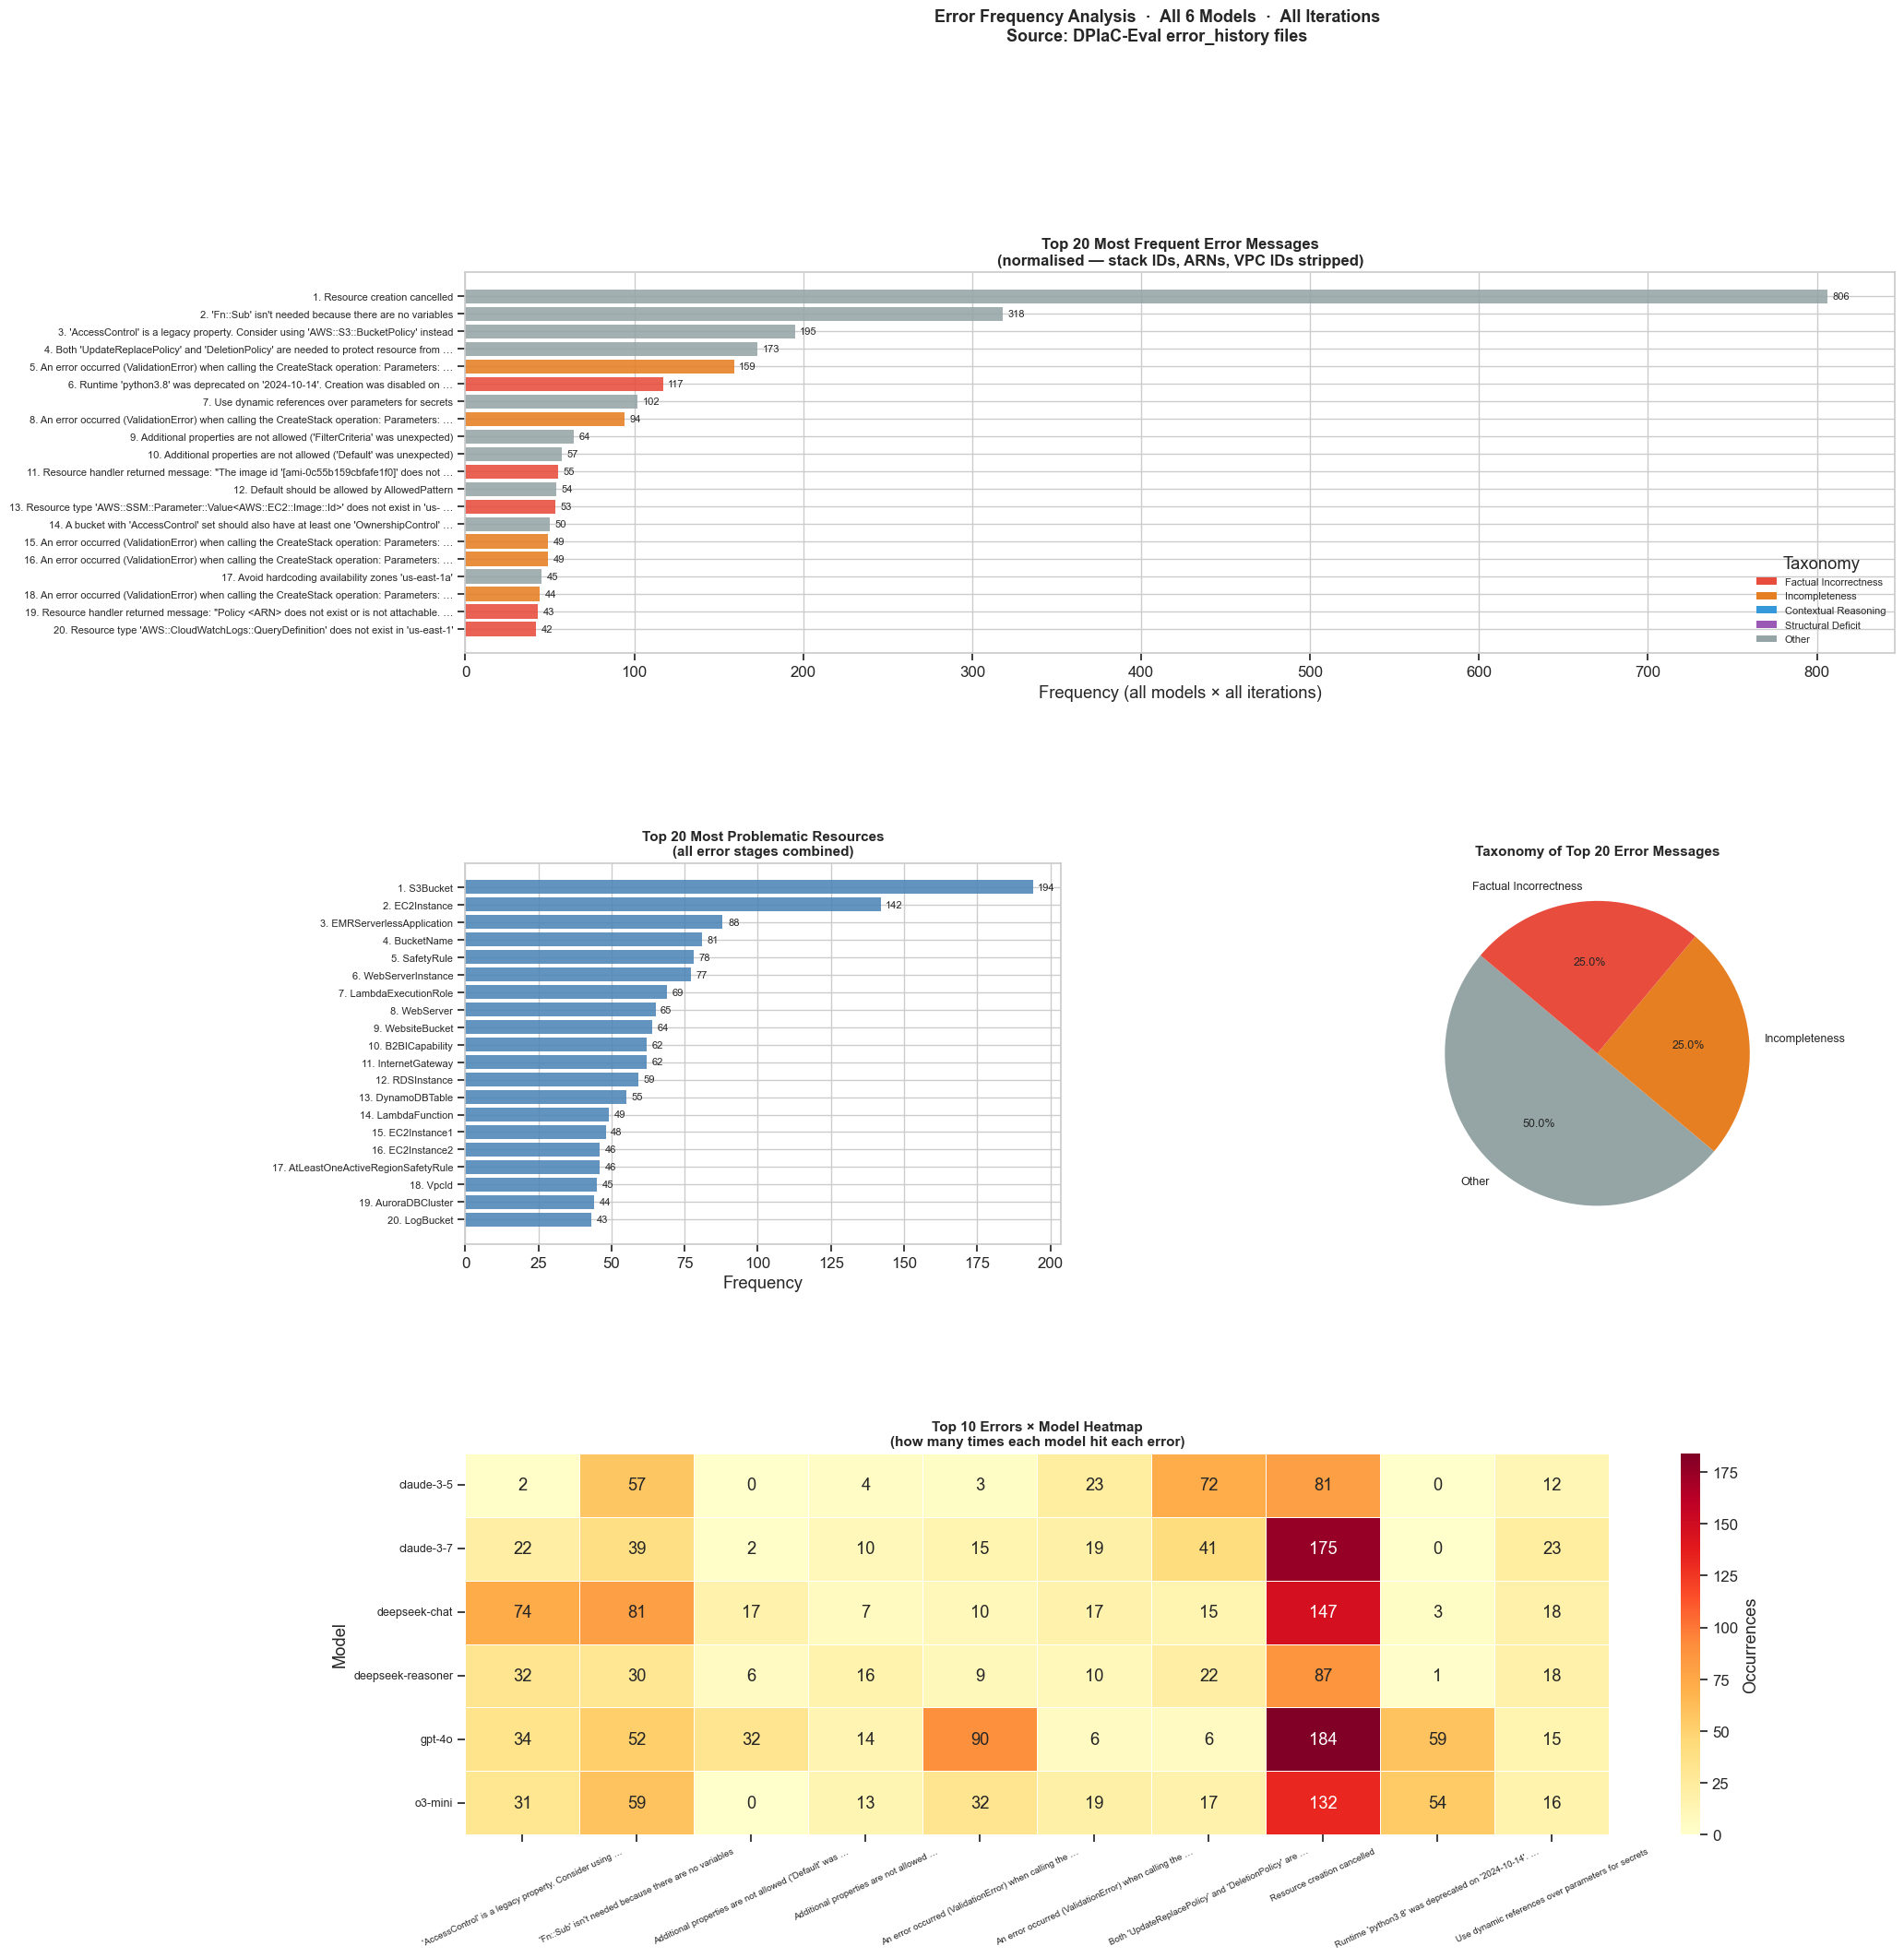

TOP 20 ERROR MESSAGES


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_86938/155108173.py:164: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda t: f'color: {TAX_COLOURS.get(t, "black")}; font-weight: bold',


,frequency,taxonomy,error_message (truncated)
rank,,,
1,806,Other,Resource creation cancelled
2,318,Other,'Fn::Sub' isn't needed because there are no variables
3,195,Other,'AccessControl' is a legacy property. Consider using 'AWS::S3::BucketPolicy' instead
4,173,Other,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from …
5,159,Incompleteness,An error occurred (ValidationError) when calling the CreateStack operation: Parameters: …
6,117,Factual Incorrectness,Runtime 'python3.8' was deprecated on '2024-10-14'. Creation was disabled on …
7,102,Other,Use dynamic references over parameters for secrets
8,94,Incompleteness,An error occurred (ValidationError) when calling the CreateStack operation: Parameters: …
9,64,Other,Additional properties are not allowed ('FilterCriteria' was unexpected)




TOP 20 MOST PROBLEMATIC RESOURCES


,resource,frequency
rank,,
1,S3Bucket,194
2,EC2Instance,142
3,EMRServerlessApplication,88
4,BucketName,81
5,SafetyRule,78
6,WebServerInstance,77
7,LambdaExecutionRole,69
8,WebServer,65
9,WebsiteBucket,64


In [39]:
# =============================================================================
# SECTION 11 – Top 20 Error Messages & Resources by Frequency
# =============================================================================

import textwrap

pd.set_option('display.max_colwidth', None)

# ── Helper: truncate long messages for display ────────────────────────────────
def truncate(msg, width=90):
    return textwrap.shorten(str(msg), width=width, placeholder=' …')

# ── 1. Normalise error messages (strip stack-specific IDs & ARNs) ─────────────
def normalise_msg(msg):
    msg = str(msg)
    # Remove ARNs
    msg = re.sub(r'arn:[^\s\'"]+', '<ARN>', msg)
    # Remove hex stack suffixes  e.g.  validation-stack-bbf87b20-bucket-uduyyl402gtk
    msg = re.sub(r'validation-stack-[a-z0-9\-]+', '<STACK>', msg)
    # Remove Request IDs
    msg = re.sub(r'RequestToken:[^\)]+', 'RequestToken:<ID>', msg)
    msg = re.sub(r'Request ID:[^\)]+',   'Request ID:<ID>',   msg)
    # Remove dynamic IP / VPC / subnet IDs
    msg = re.sub(r"'vpc-[a-z0-9]+'",    "'<VPC_ID>'",   msg)
    msg = re.sub(r"'subnet-[a-z0-9]+'", "'<SUBNET_ID>'", msg)
    msg = re.sub(r"'sg-[a-z0-9]+'",     "'<SG_ID>'",    msg)
    return msg.strip()

history_df['norm_message'] = history_df['error_message'].apply(normalise_msg)

# ── 2. Top 20 Error Messages ──────────────────────────────────────────────────
top_errors = (
    history_df['norm_message']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'norm_message': 'error_message', 'count': 'frequency'})
)
top_errors['taxonomy'] = top_errors['error_message'].apply(classify_error)
top_errors['rank']     = range(1, 21)
top_errors['error_short'] = top_errors['error_message'].apply(lambda x: truncate(x, 90))

# ── 3. Top 20 Resources ───────────────────────────────────────────────────────
top_resources = (
    history_df['resource_name']
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'resource_name': 'resource', 'count': 'frequency'})
)
top_resources['rank'] = range(1, 21)

# ── 4. Per-model error frequency (top 10 errors across models) ───────────────
top10_msgs = top_errors['error_message'].head(10).tolist()
model_error_heat = (
    history_df[history_df['norm_message'].isin(top10_msgs)]
    .groupby(['model_key', 'norm_message'])
    .size()
    .unstack(fill_value=0)
)
# Shorten column labels for heatmap
model_error_heat.columns = [truncate(c, 55) for c in model_error_heat.columns]

# ── 5. PLOT ───────────────────────────────────────────────────────────────────
TAX_COLOURS = {
    'Factual Incorrectness': '#e74c3c',
    'Incompleteness':        '#e67e22',
    'Contextual Reasoning':  '#3498db',
    'Structural Deficit':    '#9b59b6',
    'Other':                 '#95a5a6',
}

fig = plt.figure(figsize=(20, 22))
gs  = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.4)

# ── Panel A: Top 20 Error Messages horizontal bar ────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
colours_a = [TAX_COLOURS[t] for t in top_errors['taxonomy']]
bars_a = ax_a.barh(
    top_errors['rank'].astype(str) + '. ' + top_errors['error_short'],
    top_errors['frequency'],
    color=colours_a, alpha=0.88
)
ax_a.invert_yaxis()
ax_a.set_xlabel('Frequency (all models × all iterations)')
ax_a.set_title('Top 20 Most Frequent Error Messages\n(normalised — stack IDs, ARNs, VPC IDs stripped)',
               fontsize=12, fontweight='bold')
for bar in bars_a:
    ax_a.annotate(f'{int(bar.get_width())}',
                  xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                  xytext=(4, 0), textcoords='offset points',
                  va='center', fontsize=8)
# Taxonomy legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in TAX_COLOURS.items()]
ax_a.legend(handles=legend_elements, loc='lower right', fontsize=8, title='Taxonomy')
ax_a.tick_params(axis='y', labelsize=8)

# ── Panel B: Top 20 Resources horizontal bar ─────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
ax_b.barh(
    top_resources['rank'].astype(str) + '. ' + top_resources['resource'],
    top_resources['frequency'],
    color='steelblue', alpha=0.85
)
ax_b.invert_yaxis()
ax_b.set_xlabel('Frequency')
ax_b.set_title('Top 20 Most Problematic Resources\n(all error stages combined)', fontsize=11, fontweight='bold')
for bar in ax_b.patches:
    ax_b.annotate(f'{int(bar.get_width())}',
                  xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                  xytext=(4, 0), textcoords='offset points',
                  va='center', fontsize=8)
ax_b.tick_params(axis='y', labelsize=8)

# ── Panel C: Error taxonomy breakdown of top 20 errors ───────────────────────
ax_c = fig.add_subplot(gs[1, 1])
tax_counts = top_errors['taxonomy'].value_counts()
ax_c.pie(
    tax_counts,
    labels=tax_counts.index,
    autopct='%1.1f%%',
    colors=[TAX_COLOURS[t] for t in tax_counts.index],
    startangle=140,
    textprops={'fontsize': 9}
)
ax_c.set_title('Taxonomy of Top 20 Error Messages', fontsize=11, fontweight='bold')

# ── Panel D: Per-model heatmap of top 10 errors ───────────────────────────────
ax_d = fig.add_subplot(gs[2, :])
sns.heatmap(
    model_error_heat,
    ax=ax_d,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.4,
    cbar_kws={'label': 'Occurrences'}
)
ax_d.set_title('Top 10 Errors × Model Heatmap\n(how many times each model hit each error)',
               fontsize=11, fontweight='bold')
ax_d.set_xlabel('')
ax_d.set_ylabel('Model')
ax_d.tick_params(axis='x', labelsize=7, rotation=25)
ax_d.tick_params(axis='y', labelsize=9, rotation=0)

plt.suptitle(
    'Error Frequency Analysis  ·  All 6 Models  ·  All Iterations\n'
    'Source: DPIaC-Eval error_history files',
    fontsize=13, y=1.01, fontweight='bold'
)
plt.show()

# ── 6. Display clean tables ───────────────────────────────────────────────────
print("=" * 100)
print("TOP 20 ERROR MESSAGES")
print("=" * 100)
display(
    top_errors[['rank', 'frequency', 'taxonomy', 'error_short']]
    .rename(columns={'error_short': 'error_message (truncated)'})
    .set_index('rank')
    .style
    .background_gradient(subset=['frequency'], cmap='Reds')
    .applymap(lambda t: f'color: {TAX_COLOURS.get(t, "black")}; font-weight: bold',
              subset=['taxonomy'])
)

print("\n")
print("=" * 60)
print("TOP 20 MOST PROBLEMATIC RESOURCES")
print("=" * 60)
display(
    top_resources[['rank', 'resource', 'frequency']]
    .set_index('rank')
    .style
    .background_gradient(subset=['frequency'], cmap='Blues')
)
